In [1]:
import os
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colormaps
import numpy as np
import pandas as pd

plt.rcParams['font.family'] = 'Times New Roman'
matplotlib.style.use('tableau-colorblind10') #seaborn-v0_8-whitegrid  tableau-colorblind10

In [2]:
len_cf = 101  # add 1 as CFs value starting from year_0
MYs = [2020, 2030, 2040, 2050] #2020,  2060, 2070]
ssps = ["119", "245", "585"]   #"126"
sp_col, my_col = [], []

In [3]:
# below two changes from old approach: 
#1. change to: _fair_start1750MY
#2. change "metrics" folder to "metrics_2026-02-23"

ghggass = [ "CH4", "N2O"]  #CO2 

from collections import defaultdict
#  3-layer nested dict
cf_col_gas_allgas = defaultdict(lambda: defaultdict(dict))

for ghggas in ghggass: 
    cf_col_gas = []
    for sp in ssps:
        for MY in MYs:
            #print(f"read point GWP value for {ghggas} SSP {sp}, model year {MY}")
            filename = "agwp_dcf_gwp100_tstep1" + ghggas + "_ssp" + sp + "_fair_start1750MY" + str(MY) + ".xlsx"
            cf_file = os.path.join("../FaIR_dpCFs/output/metrics_2026-02-23/", filename)

            cf_agwp_df = pd.read_excel(cf_file, sheet_name = "agwp_pointvalue" + ghggas+ "_" + str(MY) ) 
            cf_agwp_pointvalue = cf_agwp_df[ghggas].values
            cf_col_gas.append(cf_agwp_pointvalue)
    
            cf_col_gas_allgas[ghggas][f'ssp{sp}'][str(MY)] = cf_agwp_pointvalue

In [4]:
cf_col_gas_allgas['CH4']['ssp119']['2030']

array([0.00000000e+00, 2.12380718e-13, 4.06260670e-13, 5.83405462e-13,
       7.45335004e-13, 8.93379974e-13, 1.02869940e-12, 1.15246538e-12,
       1.26543434e-12, 1.36858747e-12, 1.46290098e-12, 1.54919327e-12,
       1.62764649e-12, 1.69919467e-12, 1.76543013e-12, 1.82574216e-12,
       1.88067960e-12, 1.93085055e-12, 1.97666451e-12, 2.01789550e-12,
       2.05656200e-12, 2.09147428e-12, 2.12319754e-12, 2.15214394e-12,
       2.17855238e-12, 2.20264104e-12, 2.22460908e-12, 2.24463834e-12,
       2.26334174e-12, 2.28030850e-12, 2.29553082e-12, 2.30937330e-12,
       2.32169660e-12, 2.33326611e-12, 2.34391926e-12, 2.35339711e-12,
       2.36199984e-12, 2.36980091e-12, 2.37686744e-12, 2.38326078e-12,
       2.38903701e-12, 2.39416122e-12, 2.39876329e-12, 2.40289480e-12,
       2.40659476e-12, 2.40989880e-12, 2.41283953e-12, 2.41544678e-12,
       2.41774782e-12, 2.41976762e-12, 2.42166447e-12, 2.42334122e-12,
       2.42479317e-12, 2.42603826e-12, 2.42709294e-12, 2.42797230e-12,
      

### for the first 101 values, compare with the old approach: 
- Maximum % difference ≈ 0.56%
- Average % difference ≈ 0.32% 

In [5]:
agwp_co2 =  pd.read_excel('AGWP_CO2_fixed.xlsx' )
agwp_co2_TH101 = agwp_co2.iloc[:101]
#agwp_co2_TH101

agwp_co2_vals = agwp_co2_TH101['AGWP_CO2_fixed'].values[1:]  # shape (100,)
agwp_co2_vals.shape

(100,)

### calculate dpGWP[CH4/N2O] but with fixed AGWP[CO2] (not changing per MY/SSP)

In [6]:

# Output dictionary to store GWP values
gwp_results = {}

for ghg in cf_col_gas_allgas:
    gwp_results[ghg] = {}
    for ssp in cf_col_gas_allgas[ghg]:
        gwp_results[ghg][ssp] = {}
        
        for MY in cf_col_gas_allgas[ghg][ssp]:
            arr = cf_col_gas_allgas[ghg][ssp][MY]

            arr_trimmed = arr[1:101]  # drops 0th element, keeps next 100

            # get GWP values (elementwise divide by CO2 AGWP)
            gwp_array = arr_trimmed / agwp_co2_vals

            # Store result
            gwp_results[ghg][ssp][MY] = gwp_array

### dpGWP[CH4] now follows it's absolute metric trend where SSP119 have higher CFs than SSP585

In [7]:
gwp_results['CH4']['ssp119']['2030']

array([128.64236629, 126.92820887, 124.9856947 , 122.85409284,
       120.57092092, 118.1683849 , 115.69010696, 113.14257523,
       110.56211571, 107.98239693, 105.42356474, 102.86569078,
       100.34292594,  97.9208274 ,  95.53737461,  93.20330928,
        90.93148591,  88.72458721,  86.55849692,  84.50612928,
        82.50272102,  80.56056563,  78.68493791,  76.87459364,
        75.12803283,  73.4435652 ,  71.81936392,  70.26738412,
        68.76749829,  67.31377761,  65.91167335,  64.55216233,
        63.25174823,  62.00086887,  60.78846175,  59.61866173,
        58.48970076,  57.39986978,  56.34752065,  55.33106716,
        54.34702875,  53.39590417,  52.47648188,  51.58740427,
        50.72737351,  49.89514984,  49.08954969,  48.30944364,
        47.55375445,  46.82407354,  46.11705102,  45.43129578,
        44.76593602,  44.12014041,  43.49311632,  42.88394599,
        42.29067893,  41.71409604,  41.15353644,  40.60837015,
        40.07799656,  39.56184304,  39.05936349,  38.57

In [8]:
gwp_results['CH4']['ssp585']['2030']

array([121.11556054, 119.02462765, 116.7726628 , 114.32850829,
       111.78066425, 109.14871776, 106.47630161, 103.80423411,
       101.13050431,  98.48974558,  95.88473248,  93.32744091,
        90.8065039 ,  88.36791897,  85.98968725,  83.71624674,
        81.4907866 ,  79.3522124 ,  77.29762478,  75.30487355,
        73.38636825,  71.55597735,  69.79596568,  68.09489363,
        66.44877862,  64.86757726,  63.34882792,  61.89004953,
        60.49169489,  59.15730468,  57.87428267,  56.64041227,
        55.45353669,  54.31156621,  53.21248324,  52.14513337,
        51.11571073,  50.12482408,  49.1706496 ,  48.25144994,
        47.36557183,  46.51144344,  45.68757143,  44.89253791,
        44.12499726,  43.38586484,  42.67281376,  41.98330647,
        41.31628404,  40.6707415 ,  40.04572524,  39.44033034,
        38.85369815,  38.28501382,  37.73350406,  37.1984349 ,
        36.6791096 ,  36.17486666,  35.6850779 ,  35.20914667,
        34.74650615,  34.29661771,  33.85896934,  33.43

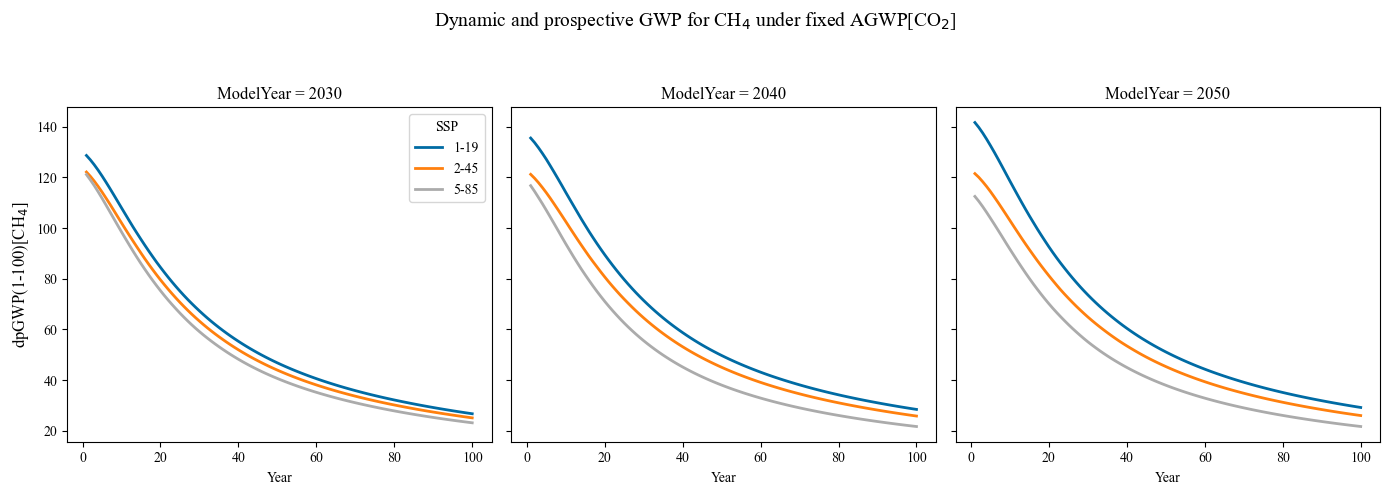

In [9]:

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
years = range(1, 101)

model_years = ['2030', '2040', '2050']
ssp_labels = {'ssp119': '1-19', 'ssp245': '2-45', 'ssp585': '5-85'}

for i, my in enumerate(model_years):
    ax = axes[i]

    # Plot each SSP line
    for ssp in ['ssp119', 'ssp245', 'ssp585']:
        gwp = gwp_results['CH4'][ssp][my]
        ax.plot(years, gwp, label=ssp_labels[ssp], linewidth=2)

    ax.set_title(f'ModelYear = {my}')
    ax.set_xlabel('Year')
    if i == 0:
        ax.set_ylabel(r'dpGWP(1-100)[CH$_4$]', fontsize = 12 )
        ax.legend(title='SSP')  # Only add legend to the first subplot
        
    #ax.grid(True)
 
fig.suptitle(r'Dynamic and prospective GWP for CH$_4$ under fixed AGWP[CO$_2$]', fontsize=14)
handles, labels = axes[0].get_legend_handles_labels()

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

### dpGWP[N2O] doesn't really change a lot, per future MY/SSP, caz now AGWP[CO2] fixed, also the N2O itself doesn't change per MY/SSP as CH4 does 

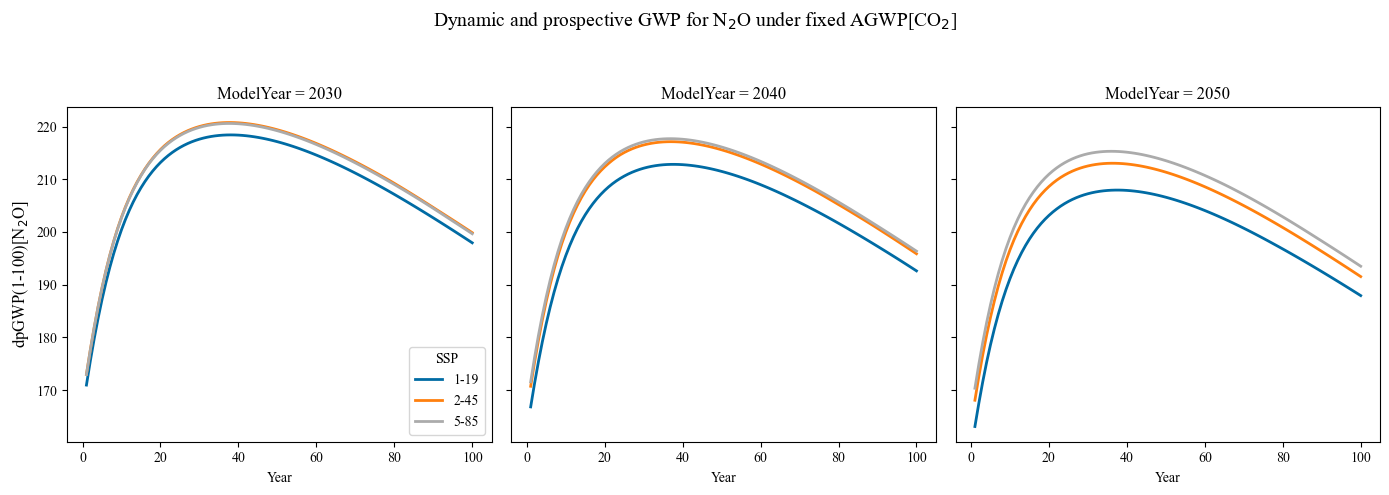

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
years = range(1, 101)

model_years = ['2030', '2040', '2050']
ssp_labels = {'ssp119': '1-19', 'ssp245': '2-45', 'ssp585': '5-85'}

for i, my in enumerate(model_years):
    ax = axes[i]

    # Plot each SSP line
    for ssp in ['ssp119', 'ssp245', 'ssp585']:
        gwp = gwp_results['N2O'][ssp][my]
        ax.plot(years, gwp, label=ssp_labels[ssp], linewidth=2)

    ax.set_title(f'ModelYear = {my}')
    ax.set_xlabel('Year')
    if i == 0:
        ax.set_ylabel(r'dpGWP(1-100)[N$_2$O]', fontsize = 12 )
        ax.legend(title='SSP')  # Only add legend to the first subplot
        
    #ax.grid(True)
 
fig.suptitle(r'Dynamic and prospective GWP for N$_2$O under fixed AGWP[CO$_2$]', fontsize=14)
handles, labels = axes[0].get_legend_handles_labels()

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

### convert dict to DF then to .nc

In [12]:
records = []

for ssp in gwp_results['CH4'].keys():
    for my in gwp_results['CH4'][ssp].keys():
        # Add Year 0 first
        records.append((ssp, my, 0, 1.0, 0.0, 0.0))  # CO2 GWP = 1.0 by default

        for year in range(1, 101):
            co2 = 1.0  # Static CO2 GWP
            ch4 = gwp_results['CH4'][ssp][my][year - 1]
            n2o = gwp_results['N2O'][ssp][my][year - 1]
            records.append((ssp, my, year, co2, ch4, n2o))

# Step 2: Create DataFrame
df = pd.DataFrame(records, columns=["SSP", "ModelYear", "Year", "CO2_GWP", "CH4_GWP", "N2O_GWP"])
df = df.set_index(["SSP", "ModelYear", "Year"])
df

CO2_GWP     CH4_GWP     N2O_GWP
SSP    ModelYear Year                                 
ssp119 2020      0         1.0    0.000000    0.000000
                 1         1.0  124.711890  174.624103
                 2         1.0  122.708084  179.353413
                 3         1.0  120.505914  183.710051
                 4         1.0  118.163336  187.700423
...                        ...         ...         ...
ssp585 2050      96        1.0   22.472404  195.437515
                 97        1.0   22.282256  194.956082
                 98        1.0   22.095961  194.472989
                 99        1.0   21.912990  193.988329
                 100       1.0   21.733252  193.502192

[1212 rows x 3 columns]

In [13]:
#Deleting rows with YEAR_index value 0 
cf_df_filtered = df[~df.index.get_level_values("Year").isin([0])]
#cf_df_filtered

print(len(df), len(cf_df_filtered))

1212 1200


In [15]:
cf_xr = df.to_xarray() 
cf_xr2 = cf_df_filtered.to_xarray() 

In [16]:
cf_xr.to_netcdf('output_dpGWP_fixedCO2/CF_v2026_GWP0_100_perSSP_MY_majorghgs.nc')
cf_xr2.to_netcdf('output_dpGWP_fixedCO2/CF_v2026_GWP1_100_perSSP_MY_majorghgs.nc')

In [ ]:
cf_xr2

In [17]:
df.to_excel("GWP_output_v2026_fixed_AGWPCO2.xlsx", index = True)